## **Name:** Nico Montoya

## **Computing ID:** zzm5rx

In [2]:
import pandas as pd
import numpy as np

import time, requests, pandas as pd
from bs4 import BeautifulSoup
import matplotlib.pyplot as plt

# Lab 1: Web Scraping & APIs (100 pts)
## Due September 22nd at 11:59PM

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/drive/1iwoJjEGsY2ej0s9i0iPXw50qpjNoDf_p?usp=sharing)


A great source of data and Pandas practice is getting data from the Internet. Rather than a .csv file, many data will be in a stream of records, typically in XML (eXtensible Mark-up Language) or JSON (JavaScript Object Notation) format.

## Overview

You will collect data three ways and assemble it into Pandas DataFrames:

1. Scrape a Wikipedia page for two different HTML tags (20 pts total)

2. Scrape any non-Wikipedia HTML page for a (different) tag of interest (40 pts)

3. Use the PokeAPI to collect data using 5+ API queries (40 pts)

## Deliverable
For each section, put collected data into a Pandas DataFrame.

**Exception:** If a required tag’s content is only available inside an image (e.g., charts, logos),  plot the image URL(s) directly instead.

# **Part 1: Scrape a Wikipedia page for two different tags (20 pts)**


In Part 1, you will pick any single Wikipedia article and extract two distinct HTML tag types (ie: H1, H2, p, a, img). You will create a DataFrame per tag type and display the results.

## **Question 1 (5 points):** Pick a Wikipedia URL to web scrape data from. Decide which 2 HTML tags you would like to scrape (a comprehensive list is above).

Save the URL and tags as string and write them in the code cell below.

In [3]:
url_str = "https://en.wikipedia.org/wiki/Quokka"
tag1 = "h1"
tag2 = "h2"


## **Question 2 (5 points):** Write code to download your initial raw data using the `requests` package and store it in a variable.



In [4]:
# Code to extract raw data here
headers = {'User-Agent': 'Mozilla/5.0 (student-lab)'}
response = requests.get(url_str, headers=headers)
soup = BeautifulSoup(response.content, 'html.parser')
tag1_elements = soup.find_all(tag1)
tag2_elements = soup.find_all(tag2)


## **Question 3 (10 points):** Extract your 2 chosen tags from your raw data and display the results. If the tag is text-based, create a DataFrame for the resulting tag contents. If the tag is image-based, plot 1 to 3 of your resulting images in the same figure.

If both tags are text based, you will create a separate DataFrame per tag.


In [5]:
# Code to display your DataFrame(s) or images here
tag1_raw = [h.get_text() for h in tag1_elements]
display(pd.DataFrame(tag1_raw, columns=["Header 1"]))

tag2_raw = [h.get_text() for h in tag2_elements]
display(pd.DataFrame(tag2_raw, columns=["Header 2"]))

,Header 1
0,Quokka


,Header 2
0,Contents
1,Description
2,Discovery and name
3,Ecology
4,Diet
5,Population
6,Conservation
7,Human interaction
8,Quokka selfies
9,See also


# **Part 2: Scrape a Non-Wikipedia page (40 pts)**


**Web Scraping Examples**
* https://toscrape.com/
* https://www.scrapethissite.com/
* https://github.com/stanfordjournalism/search-script-scrape

In Part 2, you will choose any publicly accessible page (NOT Wikipedia) and build a DataFrame with at least 10 or more rows. The structure of the DataFrame and what tag(s) you extract will be your choice.

Examples of targets: a university course listing page, a simple product listing, a blog archive page, a conference schedule.


## **Question 1 (10 points):** Write code to connect to your chosen URL, download your initial raw data using the `requests` package, and store it in a variable. Decide which tag(s) you will scrape and store them in the list, mytags.



In [6]:
url = "https://books.toscrape.com/"
mytags = ["p", "a"]

In [7]:
# Code to extract raw data here
headers = {'User-Agent': 'Mozilla/5.0 (student-lab)'}
response = requests.get(url, headers=headers)
raw_data = response.text


## **Question 2 (20 points):** Extract your chosen tag(s) from your raw data and display the results. Like before, create a DataFrame for text based tags. If the tag is image-based, plot 1 to 3 of your resulting images in the same figure.



In [8]:
# Code to extract raw data here
soup = BeautifulSoup(raw_data, 'html.parser')
mytags_elements = soup.find_all(mytags)

tag_data = []
for tag in mytags_elements:
  tag_data.append({
      "TagName": tag.name,
      "Text": tag.get_text(strip=True),
      "Attributes": tag.attrs
  })
df = pd.DataFrame(tag_data)
display(df)

,TagName,Text,Attributes
0,a,Books to Scrape,{'href': 'index.html'}
1,a,Home,{'href': 'index.html'}
2,a,Books,{'href': 'catalogue/category/books_1/index.html'}
3,a,Travel,{'href': 'catalogue/category/books/travel_2/in...
4,a,Mystery,{'href': 'catalogue/category/books/mystery_3/i...
...,...,...,...
149,p,,"{'class': ['star-rating', 'Two']}"
150,a,It's Only the Himalayas,{'href': 'catalogue/its-only-the-himalayas_981...
151,p,Â£45.17,{'class': ['price_color']}
152,p,In stock,"{'class': ['instock', 'availability']}"



## **Question 3 (10 points):** Mine one or more of your resulting DataFrames to answer a question. Questions may be quantitative or qualitative. Here are a few examples to get you started, based on the books storefront example link.


*Quantitative*
*   What is the average book price?
*   What is the range (minimum and maximum) of book prices?
*   What is the most and least expensive book?
*   How many books are 5 star rated?

*Qualitative*
*   What are the 5 star books?
*   What are the images of 5 star books? How do they compare to the 1 star books?
*  What factors contribute to if a book is priced high or low?
* etc...

## Discuss in 2 or more sentences your interpretation of the answer(s) to your question(s).


In [9]:
my_question = "What is the average book price?"

In [10]:
from ast import Attribute
# Code to answer your question here
price_row = df[df['Attributes']=={'class':['price_color']}]
price_num = price_row['Text'].str.replace('Â£', '').astype(float)
avg_price = price_num.mean()
print(avg_price)
print(max(price_num))
print(min(price_num))

38.048500000000004
57.25
13.99


**The results to my question were....The average price of the front page of the books to scrape website was £38.05. The maximum price for one of the books on the front page of the website was £57.25, and the minimum price for one of the books on the wesbite was £13.99.**

# **Part 3: Using an API for Data Sourcing (40 pts)**

In Part 3, you will query at least 5 Pokémon from the PokeAPI and build a DataFrame containing 5 or more columns that are interesting and comparable across Pokémon. Sample characteristics are below. If desired, another equivalent API of your choice can replace PokeAPI so long as the resulting DataFrame includes 5 or more columns.

**Example Characteristics:**
*   name
*   id
* base_experience
* height
* weight
* types (comma-joined)
* abilities (count)
* Statistics like HP/Attack
* Sprite URL (!!!)


**Alternative API Examples**
*   https://pokeapi.co/
  * Example: https://pokeapi.co/api/v2/pokemon?limit=1000&offset=0
  * Example: https://pokeapi.co/api/v2/pokemon/ditto
  * Example: https://pokeapi.co/api/v2/pokemon/pikachu
* https://place.dog/
* https://dukengn.github.io/Dog-facts-API/  
* https://apiv3.iucnredlist.org/api/v3/docs

A more exhaustive API list can be found at: https://github.com/public-apis/public-apis.

## **Question 1 (5 points):** Write below the API URLs you will scrape using the requests package. Create a reusable header dictionary and pass it through your requests.get connection. Write a sentence below on which parameter you will vary and which features (5+) you expect to scrape.
**Before starting, make a few manual connections the API using your browser and assess the output for any characteristics you might want to scrape. You can use the URL a few times to assess which parameter(s) will be your variable (ie: Pokemon Name for pokeapi).**

In [11]:
my_api_urls = ["https://pokeapi.co/api/v2/pokemon/ditto", "https://pokeapi.co/api/v2/pokemon/pikachu"]
api_header = {"User-Agent":"Mozilla/5.0 (student-lab)"}

for url in my_api_urls:
    response = requests.get(url, headers=api_header)
    print(response)

<Response [200]>
<Response [200]>


**I plan on scraping the following features that will be my columns for my DataFrame: Pokemon Name, HP, Height, Weight, Types.**

## **Question 2 (25 points):** Create the DataFrame of your selected feature(s). You might need to implement loops to extract enough clean features to use. Be creative with using iteration and data structures to get your data!



In [29]:
names = ["charmander", "squirtle", "pikachu", "turtwig", "froakie", "chimchar",
         "treecko", "piplup", "fennekin", "chespin"]  # At least 5
autocomplete_urls = ["https://pokeapi.co/api/v2/pokemon/" + x for x in names]

rows = []
for url in autocomplete_urls:
  print(url)
  r = requests.get(url, headers=api_header, timeout=20)
  r.raise_for_status()
  data = r.json()
  poke_name = data['name'].capitalize()
  height = data['height']
  weight = data['weight']
  hp = data['stats'][0]['base_stat']
  attack = data['stats'][1]['base_stat']
  defense = data['stats'][2]['base_stat']
  speed = data['stats'][5]['base_stat']
  types = ",".join([x['type']['name'].capitalize() for x in data['types']])
  rows.append({
      "Pokemon Name": poke_name,
      "Types": types,
      "Height": height,
      "Weight": weight,
      "HP": hp,
      "Attack": attack,
      "Defense": defense,
      "Speed": speed
  })
df_poke = pd.DataFrame(rows)
display(df_poke)

  # Add requests code per iteration
  # Ensure you are saving data in each iteration somehow to build a DataFrame

https://pokeapi.co/api/v2/pokemon/charmander
https://pokeapi.co/api/v2/pokemon/squirtle
https://pokeapi.co/api/v2/pokemon/pikachu
https://pokeapi.co/api/v2/pokemon/turtwig
https://pokeapi.co/api/v2/pokemon/froakie
https://pokeapi.co/api/v2/pokemon/chimchar
https://pokeapi.co/api/v2/pokemon/treecko
https://pokeapi.co/api/v2/pokemon/piplup
https://pokeapi.co/api/v2/pokemon/fennekin
https://pokeapi.co/api/v2/pokemon/chespin


,Pokemon Name,Types,Height,Weight,HP,Attack,Defense,Speed
0,Charmander,Fire,6,85,39,52,43,65
1,Squirtle,Water,5,90,44,48,65,43
2,Pikachu,Electric,4,60,35,55,40,90
3,Turtwig,Grass,4,102,55,68,64,31
4,Froakie,Water,3,70,41,56,40,71
5,Chimchar,Fire,5,62,44,58,44,61
6,Treecko,Grass,5,50,40,45,35,70
7,Piplup,Water,4,52,53,51,53,40
8,Fennekin,Fire,4,94,40,45,40,60
9,Chespin,Grass,4,90,56,61,65,38


## **Question 3 (10 points):** Display your resulting DataFrame. Create 3 plots of your choice that summarize the features you've collected.
* If you've scraped quantitative data, plot a few ranges or distributions of data
* If you've scraped any image URLs, plot a few of them

**Optional extensions**
* If you've scraped any image URLs, add a column for file extension type
* Run some value counts on different variables
* If your columns are messy or hard to read, rename them
* Cast data types into a usable state (ie: string to integer for numerical analysis)

## After exploring, write down 1 to 2 sentences about any interestings aspects of your data (group characteristics, clear relationships between variables) or your process of getting it.

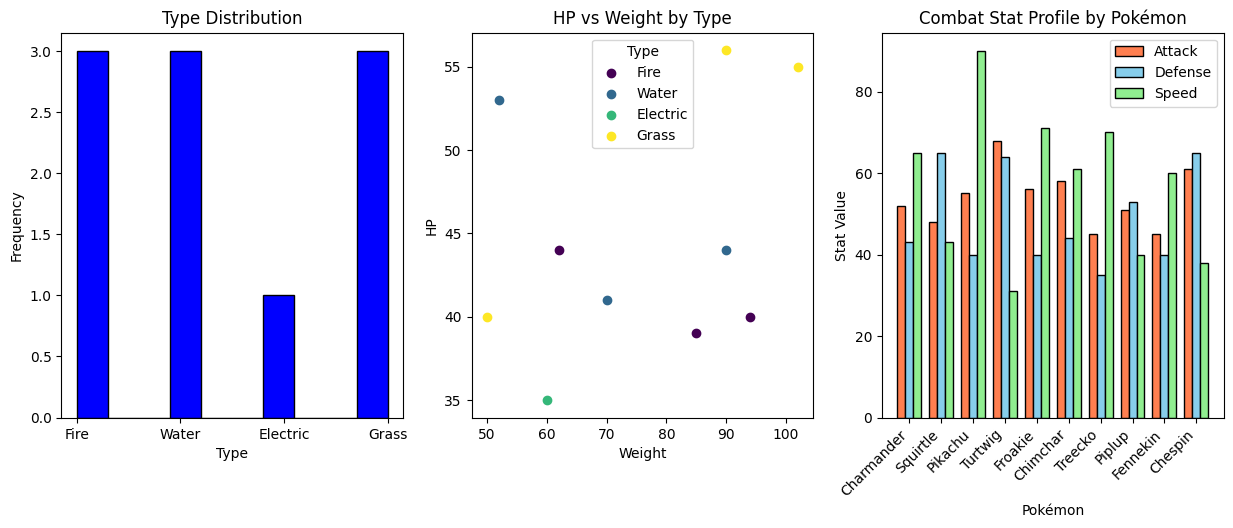

In [41]:
# Code to plot features here
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.hist(df_poke['Types'], color='blue', edgecolor='black')
plt.title('Type Distribution')
plt.xlabel('Type')
plt.ylabel('Frequency')

plt.subplot(1, 3, 2)
class_unique = df_poke['Types'].unique()
colors = plt.cm.viridis(np.linspace(0, 1, len(class_unique)))
color_map = dict(zip(class_unique, colors))

for cls in class_unique:
    subset = df_poke[df_poke['Types'] == cls]
    plt.scatter(subset['Weight'], subset['HP'], color=color_map[cls], label=cls)

plt.xlabel('Weight')
plt.ylabel('HP')
plt.title('HP vs Weight by Type')
plt.legend(title='Type', loc = 'upper center')

plt.subplot(1, 3, 3)
x = np.arange(len(df_poke["Pokemon Name"]))
width = 0.25
plt.bar(x - width, df_poke["Attack"], width, label='Attack', color='coral', edgecolor='black')
plt.bar(x, df_poke["Defense"], width, label='Defense', color='skyblue', edgecolor='black')
plt.bar(x + width, df_poke['Speed'], width, label='Speed', color='lightgreen', edgecolor='black')
plt.ylabel('Stat Value')
plt.xlabel('Pokémon')
plt.title('Combat Stat Profile by Pokémon')
plt.xticks(x, df_poke["Pokemon Name"], rotation=45, ha="right")
plt.legend()


**The results of my DataFrame show that Pokemon that have....There are 3 generations of starter pokemon data, plus the special exemption for Pikachu in Gen 1 which was clearly shown by the even distribution of types aside from the electric type pikachu. The process of grouping Types together to make the scatterplot took some trial and error to figure our but in the end resulted in data that showed that weight which can be correlated with size of pokemon doesn't have a clear relationship with HP which can be understood as life force. The syntax for the grouped bar plot was also fun to learn, and it showed what I was expected, where no one starter pokemon had stats overwhelmingly great than the other, which makes sense as they are supposed to be around equal for any trainer to start off their journey so that one doesn't get an advatange from picking on pokemon over the other. The only exeception is pikachu with a much higher speed stat, but pikachu is also not its first evolutionary form and is an exception from the more tradition Fire, Water, and Grass type starters.**

### Honor Pledge

On my honor as a student, I have neither given nor received unauthorized aid on this assignment.

Signed: Nico Montoya